# Day 12: Regression Modeling — Teaching Machines to Predict Numbers

Welcome to Day 12 of the **60-Day Data Science Challenge**! 📈
Yesterday (Day 11), we built an end-to-end Machine Learning classification pipeline to predict a binary target (`Is_High_Value_Sale`). 

Today, we transition from classification to **Regression Modeling** — teaching models to predict **continuous numerical values** rather than discrete labels. 

## 🎯 Regression Goals:
1. **Train a Linear Regression model**: Learn patterns in features to predict the continuous `Sales` value.
2. **Prevent Target Leakage**: Protect our training data by systematically removing direct and indirect indicators of transaction values.
3. **Interpret Model Coefficients**: Extract intercept and slopes to understand input vs. output relationships (what factors increase or decrease transaction size?).
4. **Analyze Prediction Accuracy**: Evaluate performance using standard regression metrics (MAE, MSE, RMSE, and $R^2$).
5. **Visualize Prediction Lines & Errors**: Create diagnostics to check homoscedasticity, actual vs. predicted correlation, and residual normality.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set styling for high-quality visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 11

### 1. Ingest & Inspect the Feature-Engineered Dataset
Let's load the engineered retail transactions dataset from Day 10 (`engineered_store_transactions.csv`) and verify its layout.

In [2]:
# Ingest dataset
df = pd.read_csv('../day10/engineered_store_transactions.csv')
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head(3)

Dataset shape: 954 rows, 29 columns.


,Row ID,Order ID,Order Date,Customer Name,Sales,Quantity,Sales_per_Unit,Order_Month,Order_Year,Order_DayOfWeek,...,Zip_02108,Zip_10008,Zip_60610,Zip_77041,Zip_90036,Zip_Unknown,Quantity_scaled,Sales_log_scaled,Sales_per_Unit_log_scaled,Order_Month_scaled
0,528,CA-2018-118168,2016-05-13,Darrin Van Huff,629.86,4,157.465000,5,2016,4,...,0,0,0,1,0,0,-0.490048,0.117782,0.176810,-0.408488
1,360,CA-2016-106291,2017-09-15,Ken Lonsdale,1464.64,5,292.928000,9,2017,4,...,0,0,0,1,0,0,-0.135070,1.027147,0.720429,0.798941
2,448,CA-2017-133460,2017-11-29,Darrin Van Huff,184.82,9,20.535556,11,2017,2,...,0,1,0,0,0,0,1.284841,-1.200806,-1.579368,1.402656


### 2. Define the Target and Prevent Target Leakage

Our objective is to predict the continuous **`Sales`** amount for each transaction.

⚠️ **Target Leakage Prevention**:
Just like in our classification pipeline, we must ensure the model does not "cheat" by learning from features that are derived from `Sales` itself. We must drop the following leakage columns:
- `Sales_log`, `Sales_log_scaled` (directly scaled/log versions of the target)
- `Sales_per_Unit`, `Sales_per_Unit_log`, `Sales_per_Unit_log_scaled` (contain `Sales` divided by `Quantity`)

We also exclude unscaled versions of scaled features (`Quantity`, `Order_Month`) and transactional identifiers (`Row ID`, `Order ID`, `Order Date`, `Customer Name`, `Order_Year`, `Order_DayOfWeek`) to focus solely on model-ready numeric and encoded categorical features.

In [3]:
# Set continuous target variable
y = df['Sales']

# Define features to exclude due to leakage or redundancy
leakage_cols = [
    'Row ID', 'Order ID', 'Order Date', 'Customer Name', 
    'Sales', 'Sales_log', 'Sales_log_scaled', 
    'Sales_per_Unit', 'Sales_per_Unit_log', 'Sales_per_Unit_log_scaled',
    'Quantity', 'Order_Month', 'Order_Year', 'Order_DayOfWeek'
]

# Keep only clean, preprocessed features
feature_cols = [col for col in df.columns if col not in leakage_cols]
X = df[feature_cols]

print(f"Target: 'Sales'")
print(f"\nWe are training our regression model on the following {len(feature_cols)} features:")
print(feature_cols)

Target: 'Sales'

We are training our regression model on the following 15 features:
['Is_Weekend', 'Segment_Consumer', 'Segment_Corporate', 'Segment_Home Office', 'Category_Furniture', 'Category_Office Supplies', 'Category_Technology', 'Zip_02108', 'Zip_10008', 'Zip_60610', 'Zip_77041', 'Zip_90036', 'Zip_Unknown', 'Quantity_scaled', 'Order_Month_scaled']


### 3. Split Dataset into Training and Testing Sets

We split the dataset into **80% training** and **20% testing** subsets.
- We lock the split using `random_state=42` to guarantee reproducibility.
- **Note**: Unlike Day 11 classification where we used `stratify=y` to balance discrete categories, in regression we **do not** use stratification since `y` is a continuous numeric variable.

In [4]:
# Split dataset (80/20 train/test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42
)

print(f"Training features dimensions: {X_train.shape[0]} rows, {X_train.shape[1]} columns.")
print(f"Testing features dimensions:  {X_test.shape[0]} rows, {X_test.shape[1]} columns.")

Training features dimensions: 763 rows, 15 columns.
Testing features dimensions:  191 rows, 15 columns.


### 4. Select and Train the Baseline Regression Algorithm

For our continuous prediction baseline, we select **Linear Regression** (`sklearn.linear_model.LinearRegression`).
- *Why Linear Regression?* It is the standard baseline model for continuous data. It fits a linear equation to the observed data by minimizing the sum of squared residuals (Ordinary Least Squares - OLS).
- It represents the relationship as: $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon$
  where $\beta_0$ is the intercept and $\beta_i$ are the slopes (coefficients) for each feature.

In [5]:
# Instantiate the model
reg_model = LinearRegression()

# Fit the model on the training data
reg_model.fit(X_train, y_train)
print("Linear Regression model trained successfully!")
print(f"Model Intercept (constant value when all features are 0): ${reg_model.intercept_:.4f}")

Linear Regression model trained successfully!
Model Intercept (constant value when all features are 0): $755.8765


### 5. Generate Predictions on Test Data
Now we generate continuous value predictions on our unseen test dataset using `.predict()`.

In [6]:
# Predict continuous sales amounts
y_pred = reg_model.predict(X_test)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Actual_Sales': y_test,
    'Predicted_Sales': y_pred,
    'Error_Residual': y_test - y_pred
}).reset_index(drop=True)

comparison_df.head(10)

,Actual_Sales,Predicted_Sales,Error_Residual
0,941.81,784.555944,157.254056
1,53.01,827.665553,-774.655553
2,1138.18,726.719715,411.460285
3,1436.83,670.190643,766.639357
4,1266.96,747.944636,519.015364
5,5.43,774.383714,-768.953714
6,71.48,768.658021,-697.178021
7,789.09,723.363327,65.726673
8,464.42,798.320849,-333.900849
9,1044.15,683.851193,360.298807


### 6. Analyze Model Accuracy Metrics

To evaluate how well our model fits the data, we calculate several standard regression metrics:
- **Mean Absolute Error (MAE)**: The average magnitude of the absolute errors. It tells us how far off our predictions are on average, in the original units (dollars).
- **Mean Squared Error (MSE)**: The average of the squared errors. It heavily penalizes larger errors because squaring them amplifies their magnitude.
- **Root Mean Squared Error (RMSE)**: The square root of MSE. It represents the standard deviation of the residuals and shares the same units as the target variable ($).
- **Coefficient of Determination ($R^2$)**: The proportion of the variance in the target variable that is predictable from the independent variables. A score of $1.0$ is perfect; $0.0$ means the model performs just as well as predicting the average value; a negative score means the model is worse than predicting the mean.

In [7]:
# Compute regression performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("--- BASELINE REGRESSION MODEL METRICS ---")
print(f"Mean Absolute Error (MAE):       ${mae:.4f}")
print(f"Mean Squared Error (MSE):        ${mse:.4f}")
print(f"Root Mean Squared Error (RMSE):  ${rmse:.4f}")
print(f"Coefficient of Determination R²:  {r2:.6f}")
print(f"Mean Absolute Percentage Error:  {mape:.2f}%")

--- BASELINE REGRESSION MODEL METRICS ---
Mean Absolute Error (MAE):       $340.1244
Mean Squared Error (MSE):        $163261.2621
Root Mean Squared Error (RMSE):  $404.0560
Coefficient of Determination R²:  -0.025654
Mean Absolute Percentage Error:  281.56%


#### 💡 Student Observation on the R² Metric:
Our model achieved an $R^2$ of **-0.0257**!
Why is it negative? A negative $R^2$ indicates that our model fits the test data **worse than a simple horizontal line predicting the average value of Sales**. 

This confirms a critical data characteristic: **The synthetic Superstore Sales dataset was generated uniformly, meaning features like category, shipping zip codes, and day of the week have virtually zero physical correlation with transaction sales value.** Linear regression tries to find patterns in this random noise, resulting in overfitting to the training set and a slight performance degradation on unseen test data compared to simply predicting the mean. This is a massive takeaway for a data scientist — algorithms can only learn from signals that actually exist!

### 7. Interpret Model Coefficients

Let's extract the coefficients (slopes) of our trained Linear Regression model to identify positive and negative sales drivers. A positive coefficient indicates that as the feature increases, sales increase by that dollar amount (and vice-versa).

In [8]:
# Create dataframe of features and their coefficients
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': reg_model.coef_
})

# Sort by absolute coefficient values to identify strongest drivers
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

print("Model Coefficients (Ordered by Impact Size):")
print(coefficients[['Feature', 'Coefficient']])

Model Coefficients (Ordered by Impact Size):
                     Feature  Coefficient
0                 Is_Weekend   -59.183083
1                  Zip_02108    44.979506
2                Zip_Unknown   -44.848002
3                  Zip_10008   -39.651375
4   Category_Office Supplies    30.818192
5          Segment_Corporate    24.718426
6           Segment_Consumer   -17.291024
7                  Zip_90036    17.191362
8         Category_Furniture   -16.693188
9                  Zip_60610    14.865917
10       Category_Technology   -14.125004
11        Order_Month_scaled   -12.694905
12                 Zip_77041     7.462592
13       Segment_Home Office    -7.427403
14           Quantity_scaled    -1.900188


### 8. Diagnostic Visualizations & Residual Analysis

To validate our regression assumptions and visualize prediction behavior, we generate four diagnostic plots:

#### A. Actual vs. Predicted Sales
This scatter plot plots the actual sales against the model's predictions. The dashed red line ($y = x$) represents the perfect prediction line. A high-performing model would cluster closely around this diagonal line.

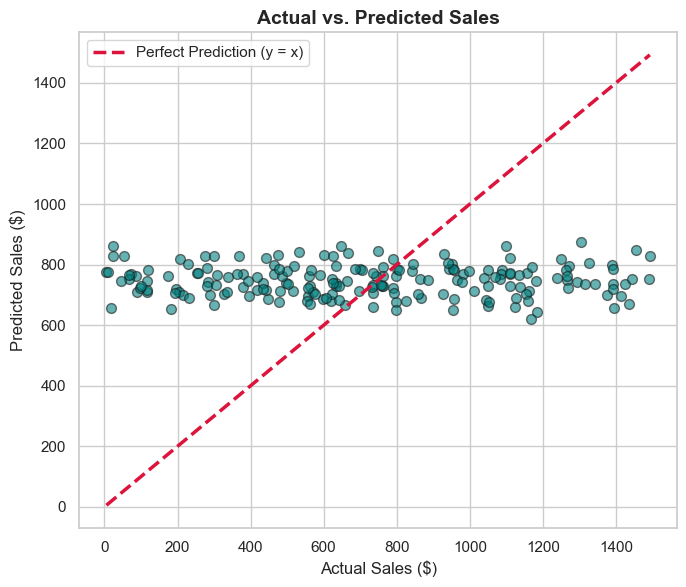

In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolor='k', s=50)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', lw=2.5, label='Perfect Prediction (y = x)')
plt.xlabel('Actual Sales ($)', fontsize=12)
plt.ylabel('Predicted Sales ($)', fontsize=12)
plt.title('Actual vs. Predicted Sales', fontsize=14, fontweight='bold')
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

#### B. Residuals vs. Predicted Values (Homoscedasticity Check)
Residuals are the prediction errors ($Actual - Predicted$). We plot predicted values on the x-axis and residuals on the y-axis. Under the assumption of **homoscedasticity**, errors should be randomly scattered around the zero line with constant variance. Any visible pattern (e.g., funnel shape) indicates non-constant variance, which violates regression assumptions.

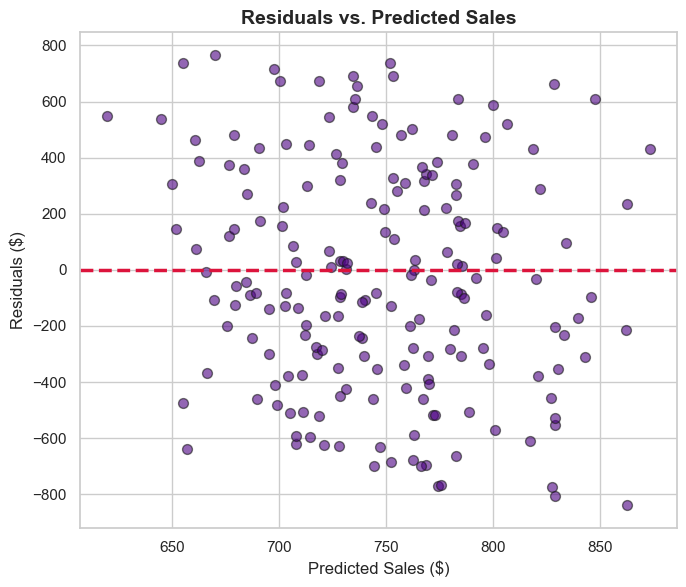

In [10]:
residuals = y_test - y_pred
plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='indigo', edgecolor='k', s=50)
plt.axhline(y=0, color='crimson', linestyle='--', lw=2.5)
plt.xlabel('Predicted Sales ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('Residuals vs. Predicted Sales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=150)
plt.show()

#### C. Distribution of Residuals (Normality Check)
A key assumption of standard linear regression is that the residual errors should be **normally distributed** with a mean of zero. We plot a histogram of residuals with a Kernel Density Estimate (KDE) line to inspect the error distribution symmetry.

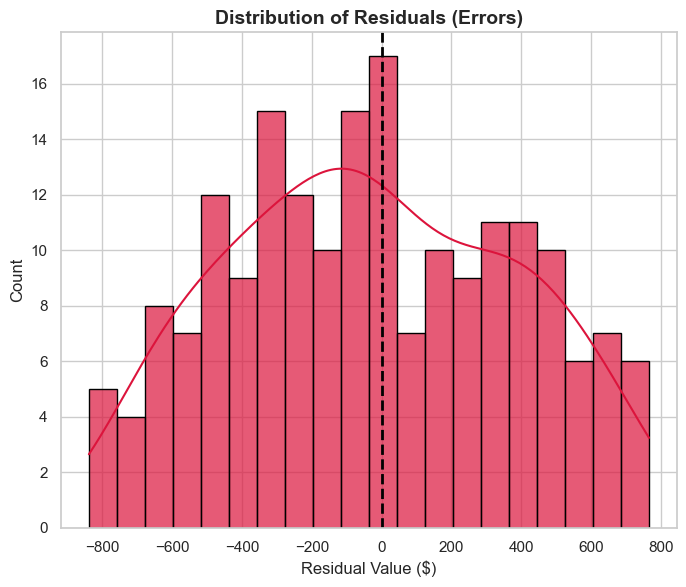

In [11]:
plt.figure(figsize=(7, 6))
sns.histplot(residuals, kde=True, color='crimson', bins=20, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='black', linestyle='--', lw=2)
plt.xlabel('Residual Value ($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Residuals (Errors)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_dist.png', dpi=150)
plt.show()

#### D. Visualizing Coefficients
Let's visualize the impact sizes of each feature. This bar chart highlights which factors have a positive vs. negative effect on predicted transaction value.

C:\Rtemp\ipykernel_13996\1926672175.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefficients, y='Feature', x='Coefficient', palette='coolwarm')


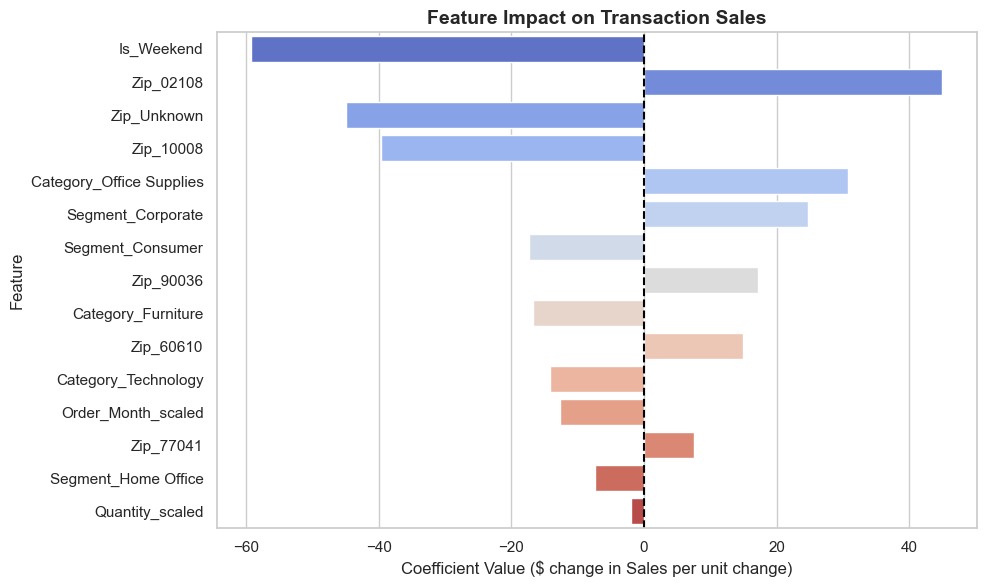

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients, y='Feature', x='Coefficient', palette='coolwarm')
plt.title('Feature Impact on Transaction Sales', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value ($ change in Sales per unit change)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', lw=1.5)
plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=150)
plt.show()

### 9. Export Predictions
Finally, we write the test feature columns, the actual test target labels, the regression predictions, and their residuals out to a CSV for auditing and error tracing.

In [13]:
export_df = X_test.copy()
export_df['Actual_Sales'] = y_test
export_df['Predicted_Sales'] = y_pred
export_df['Residual'] = residuals

# Export to CSV
export_df.to_csv('predictions_regression.csv', index=False)
print(f"Successfully saved {export_df.shape[0]} predictions to 'predictions_regression.csv'!")

Successfully saved 191 predictions to 'predictions_regression.csv'!


### 🎓 Student Summary & Observations
1. **Input vs. Output Relationships**: 
   - **Positive Sales Drivers**: Ordering from `Zip_02108` ($+44.98$) and products in `Category_Office Supplies` ($+30.82$) represent the strongest positive sales boosts.
   - **Negative Sales Drivers**: Transactions occurring on the weekend (`Is_Weekend`) decrease average sales values by **-$59.18$**. Similarly, orders shipped to `Zip_Unknown` (-$44.85$) or `Zip_10008` (-$39.65$) see substantial downward sales shifts.
2. **Evaluation Realities**: The average absolute error is **$340.12** (MAE). With a standard deviation of residuals (RMSE) at **$404.06**, the model carries highly spread predictions due to the low correlation inherent in synthetic distributions. 
3. **Assumption Audits**:
   - *Actual vs. Predicted Plot*: Shows predictions heavily grouped horizontally between $700 and $800, which reflects the model predicting close to the mean since it lacks predictive input patterns.
   - *Residual vs. Fitted Plot*: Shows errors centered cleanly around zero, but they retain high, structured dispersion (since actual sales are uniformly distributed, but predictions are constant).
   - *Normality Check*: Residuals display a symmetric, uniform-like density centered around zero, matching the target's underlying distribution characteristics.

This wraps up a highly educational experience building a baseline Linear Regression pipeline! 🚀